In [6]:
!python3 -m venv sailing-env
!source sailing-env/bin/activate
!pip install -r requirements.txt

%load_ext autoreload
%autoreload 2

from src.utils.agent_utils import save_dqn_agent

import sys
import os
import numpy as np
import random
from collections import deque
import pickle
import math
import time

# Add the src directory to the path
sys.path.append(os.path.abspath('../src'))
sys.path.append(os.path.abspath('..'))

# Import the BaseAgent class
from src.agents.base_agent import BaseAgent

from src.env_sailing import SailingEnv
from src.wind_scenarios import get_wind_scenario

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
class NeuralNetwork:
    def __init__(self, input_size=44, hidden_size_1=128, hidden_size_2 = 128, output_size=9 ,learning_rate=0.001):
        super().__init__()
        self.np_random = np.random.default_rng()
        self.learning_rate = learning_rate
        # Linear parameters
        self.W1 = np.random.randn(input_size, hidden_size_1) * np.sqrt(2./input_size)
        self.b1 = np.zeros((1, hidden_size_1))
        self.W2 = np.random.randn(hidden_size_1, hidden_size_2) * np.sqrt(2./hidden_size_1)
        self.b2 = np.zeros((1, hidden_size_2))  
        self.W3 = np.random.randn(hidden_size_2, output_size) * np.sqrt(2./hidden_size_2)
        self.b3 = np.zeros((1, output_size))

    def forward(self, X):
        self.X = np.array(X)

        self.l1 = np.dot(X, self.W1) + self.b1
        self.relu1 = np.maximum(0, self.l1) 
        self.l2 = np.dot(self.relu1, self.W2) + self.b2
        self.relu2 = np.maximum(0, self.l2) 
        self.l3 = np.dot(self.relu2, self.W3) + self.b3
        return self.l3

    def backward(self, y_pred, y_true, weights=None):
        batch_size = y_pred.shape[0]

        delta = y_pred - y_true

        if weights is not None:
            delta *= weights[:, None]
        huber_delta = 1.0
        loss_grad = np.where(np.abs(delta) < huber_delta,
                            delta,
                            huber_delta * np.sign(delta))
        dl3 = loss_grad / batch_size 
        #dl3 = 2 * (y_pred - y_true) / batch_size #mse
        dW3 = np.dot(self.relu2.T, dl3)
        db3 = np.sum(dl3, axis=0, keepdims=True)

        drelu2 = np.dot(dl3, self.W3.T)
        dl2 = drelu2 * (self.l2 > 0)
        dW2 = np.dot(self.relu1.T, dl2)
        db2 = np.sum(dl2, axis=0, keepdims=True)

        drelu1 = np.dot(dl2, self.W2.T)
        dl1 = drelu1 * (self.l1 > 0)
        dW1 = np.dot(self.X.T, dl1)
        db1 = np.sum(dl1, axis=0, keepdims=True)

        max_grad = 10.0
        for grad in [dW1, db1, dW2, db2, dW3, db3]:
            np.clip(grad, -max_grad, max_grad, out=grad)

        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1


    def copy_weights(self):
        return {
            'W1': self.W1.copy(), 'b1': self.b1.copy(),
            'W2': self.W2.copy(), 'b2': self.b2.copy(),
            'W3': self.W3.copy(), 'b3': self.b3.copy()
        }  

    def update_weights(self, weights):
        self.W1 = weights['W1'].copy()
        self.b1 = weights['b1'].copy()
        self.W2 = weights['W2'].copy()
        self.b2 = weights['b2'].copy()
        self.W3 = weights['W3'].copy()
        self.b3 = weights['b3'].copy() 
        
class DQNAgent(BaseAgent):
    def __init__(self, hidden_size_1=128, hidden_size_2=128, memory_buffer = 100000, learning_rate=0.001, discount_factor=0.9, exploration_rate=0.1):
        super().__init__()
        self.np_random = np.random.default_rng()
        self.buffer_random = random.Random()        

        # Learning parameters
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate

        self.policy_net = NeuralNetwork(22, hidden_size_1, hidden_size_2, 9, self.learning_rate)
        self.target_net = NeuralNetwork(22, hidden_size_1, hidden_size_2, 9, self.learning_rate)
        self.update_weights_target() #pour initialiser avec les mêmes poids

        self.buffer = deque(maxlen=memory_buffer) #pour stocker en mémoire
        self.priorities = deque(maxlen=memory_buffer)
        self.priority_alpha = 0.6
        self.beta = 0.4
        self.beta_increment = 1e-4

    def get_features(self, observation, training=True):
        x, y = observation[0], observation[1]
        vx, vy = observation[2], observation[3]
        wx, wy = observation[4], observation[5]
        #flattened_wind_field = observation[6:6+32768].reshape(2, 128, 128)
        flattened_world = observation[6+32768:].reshape(128,128)
        if training :
            #randomisation du vent
            theta = self.np_random.uniform(-np.pi/2, np.pi/2)
            scale = self.np_random.uniform(0.7, 1.3)

            wx, wy = wx * scale, wy * scale

            wx_rot = wx * np.cos(theta) - wy * np.sin(theta)
            wy_rot = wx * np.sin(theta) + wy * np.cos(theta)

            wx, wy = wx_rot, wy_rot

        vx = np.clip(vx, -5, 5) / 5
        vy = np.clip(vy, -5, 5) / 5
        wx = np.clip(wx, -5, 5) / 5
        wy = np.clip(wy, -5, 5) / 5

        features = []
        v = np.sqrt(vx**2+vy**2)
        features.extend([x/128, y/128, vx, vy, v])

        #feature with goal
        goal = [64, 127]
        dx, dy = goal[0] - x, goal[1] - y
        dist_to_goal = np.sqrt(dx**2 + dy**2)
        norm = np.sqrt(128**2 + 128**2)
        angle_to_goal = np.arctan2(dy, dx)
        features.extend([dist_to_goal/norm, np.cos(angle_to_goal), np.sin(angle_to_goal)])

        #vmg
        if v>0.05:
            boat_angle = np.arctan2(vy, vx)
            vmg = v * np.cos(boat_angle - angle_to_goal)
        else :
            vmg = v
            boat_angle = angle_to_goal
        features.append(vmg)

        #feature angle with wind
        wind_angle = np.arctan2(wy, wx)
        relative_wind = abs((wind_angle - boat_angle + np.pi) % (2*np.pi) - np.pi)
        wind_goal_angle = abs((wind_angle - angle_to_goal + np.pi) % (2*np.pi) - np.pi)
        features.extend([np.cos(relative_wind), np.sin(relative_wind),np.cos(wind_goal_angle), np.sin(wind_goal_angle), np.sqrt(wx**2 + wy**2)])

        #feature of danger
        direction = [(0,1), (1,1), (1,0), (1,-1), (0,-1), (-1,-1), (-1,0), (-1,1)]
        #on choisit une direction et on crée une feature de danger par rapport à l'ile
        for direction_x, direction_y in direction: 
            danger = 0
            for distance in range(1,25):
                new_x = int(x + direction_x*distance)
                new_y = int(y + direction_y*distance)
                if 0 <= new_x < 128 and 0<= new_y < 128:
                    if flattened_world[new_x,new_y] == 1:
                        danger = (25 - distance)/25 
                        break
            features.append(danger)
        
        # #features with wind around
        # for direction_x, direction_y in direction:
        #     distance = 10
        #     new_x = int(x + direction_x*distance)
        #     new_y = int(y + direction_y*distance)
        #     if 0 <= new_x < 128 and 0<= new_y < 128:
        #         if training :
        #             new_wx = flattened_wind_field[0, new_x, new_y] * scale
        #             new_wy = flattened_wind_field[1, new_x, new_y] * scale

        #             new_wx_rot = new_wx * np.cos(theta) - new_wy * np.sin(theta)
        #             new_wy_rot = new_wx * np.sin(theta) + new_wy * np.cos(theta)

        #             new_wx = np.clip(new_wx_rot, -5, 5) / 5
        #             new_wy = np.clip(new_wy_rot, -5, 5) / 5
        #             features.append(new_wx - wx)
        #             features.append(new_wy - wy)
        #         else : 
        #             new_wx = flattened_wind_field[0, new_x, new_y]
        #             new_wy = flattened_wind_field[1, new_x, new_y]
        #             features.append(new_wx - wx)
        #             features.append(new_wy - wy)
        #     else :
        #         features.append(0)
        #         features.append(0)

        # #features gradient wind
        # int_x, int_y = int(x), int(y)
        # if 1 <= int_x < 127 and 1 <= int_y < 127:
        #     dwx_dx = flattened_wind_field[0, int_x+1, int_y] - flattened_wind_field[0, int_x-1, int_y]
        #     dwx_dy = flattened_wind_field[0, int_x, int_y+1] - flattened_wind_field[0, int_x, int_y-1]
        #     dwy_dx = flattened_wind_field[1, int_x+1, int_y] - flattened_wind_field[1, int_x-1, int_y]
        #     dwy_dy = flattened_wind_field[1, int_x, int_y+1] - flattened_wind_field[1, int_x, int_y-1]
        #     features.append(dwx_dx)
        #     features.append(dwx_dy)
        #     features.append(dwy_dx)
        #     features.append(dwy_dy)
        # else:
        #     features.append(0)
        #     features.append(0)
        #     features.append(0)
        #     features.append(0)

        #try to force to end in 40 steps
        # ideal_v = dist_to_goal / 40
        # v_deficit = ideal_v - v
        # features.append(np.clip(v_deficit, -5, 5) / 5.0)

        #features += np.random.normal(0, 0.01, size=len(features))
        
        return np.array(features)

    def act(self, observation, training=True):
        """Choose an action using epsilon-greedy policy."""
        state = self.get_features(observation, training).reshape(1, -1)
        # Epsilon-greedy action selection
        if self.np_random.random() < self.exploration_rate:
            return self.np_random.integers(0, 9)
        else:
            q_values = self.policy_net.forward(state)
            return int(np.argmax(q_values))

    def learn(self, observation, action, reward, next_observation, batch_size, done):
        """Update q_values based on observed transition."""
        state = self.get_features(observation, training=False)
        next_state = self.get_features(next_observation, training=False)

        self.buffer.append((state, action, reward, next_state, done))
        if len(self.priorities) > 0:
            max_priority = max(self.priorities)
        else :
            max_priority = 1

        self.priorities.append(max_priority)

        if len(self.buffer) < batch_size:
            return

        priorities = np.array(self.priorities, dtype=np.float32)
        probs = priorities ** self.priority_alpha
        probs /= probs.sum()

        indices = self.np_random.choice(len(self.buffer), batch_size, p=probs, replace=False)
        batch = [self.buffer[i] for i in indices]

        states, actions, rewards, next_states, dones = zip(*batch)

        states = np.array(states)
        next_states = np.array(next_states)
        rewards = np.array(rewards)
        dones = np.array(dones)
        actions = np.array(actions)

        weights = (len(self.buffer) * probs[indices]) ** (-self.beta)
        weights /= weights.max()

        current_q = self.policy_net.forward(states)
        next_q_target = self.target_net.forward(next_states)
        next_q_policy = self.policy_net.forward(next_states)

        targets = current_q.copy()
        td_errors = np.zeros(batch_size)

        for i in range(batch_size):
            target = rewards[i]

            if not dones[i]:
                best_action = np.argmax(next_q_policy[i])
                target += self.discount_factor * next_q_target[i, best_action]

            td_error = target - current_q[i, actions[i]]
            td_errors[i] = td_error

            targets[i, actions[i]] = current_q[i, actions[i]] + weights[i] * td_error

        self.policy_net.forward(states)
        self.policy_net.backward(current_q, targets, weights)

        for idx, td in zip(indices, td_errors):
            self.priorities[idx] = abs(td) + 1e-6
    def reset(self):
        """Reset the agent for a new episode."""
        # Nothing to reset
        pass
        
    def seed(self, seed=None):
        """Set the random seed."""
        self.np_random = np.random.default_rng(seed)
        self.buffer_random = random.Random(seed)
        self.policy_net.rng = np.random.default_rng(seed)
        self.target_net.rng = np.random.default_rng(seed) 
        
    def save(self, path):
        """Save the weights to a file."""
        with open(path, 'wb') as f:
            pickle.dump(self.policy_net.copy_weights(), f)
            
    def load(self, path):
        """Load the weights from a file."""
        with open(path, 'rb') as f:
            self.policy_net.update_weights(pickle.load(f))
            self.update_weights_target()
    
    def update_weights_target(self):
        self.target_net.update_weights(self.policy_net.copy_weights())

    def soft_update(self, tau=0.005):
        for attr in ['W1','b1','W2','b2','W3','b3']:
            target_param = getattr(self.target_net, attr)
            policy_param = getattr(self.policy_net, attr)

            updated = tau * policy_param + (1 - tau) * target_param
            setattr(self.target_net, attr, updated) 
        
dqn_agent = DQNAgent(hidden_size_1=64, hidden_size_2=64, memory_buffer = 25000, learning_rate=0.0005, discount_factor=0.97, exploration_rate=1)
max_steps = 500

np.random.seed(42)
dqn_agent.seed(42)

scenarios = ['training_1', 'training_2', 'training_3']
num_episodes = 4500
batch_size = 64
target_update_freq = 100

rewards_history = []
steps_history = []
success_history = []

best_avg_steps = 500
best_success = 0

eps_start = 1.0
eps_end = 0.03
eps_decay = 1200

start_time = time.time()
print(f"Starting full training with {num_episodes} episodes across 3 scenarios...")

for episode in range(num_episodes):
    # scenario = scenarios[episode % 3]
    #scenario = scenarios[np.random.randint(0, 3)]
    if episode < 1000:
        scenario = 'training_1'
    elif episode < 2000:
        scenario = scenarios[np.random.randint(0, 2)]
    else:
        scenario = scenarios[np.random.randint(0, 3)] 
    env = SailingEnv(**get_wind_scenario(scenario))
    goal = env.goal_position.copy()
    
    observation, info = env.reset(seed=episode)
    prev_dist = np.linalg.norm(info['position'] - goal)
    total_reward = 0
    previous_action = None

    if episode < 1200:
        current_max_steps = 500

    elif episode < 2200:
        current_max_steps = 300

    elif episode < 3200:
        current_max_steps = 200

    elif episode < 4000:
        current_max_steps = 140

    else:
        current_max_steps = 110

    for step in range(current_max_steps):
        action = dqn_agent.act(observation)
        next_observation, reward, done, truncated, info = env.step(action)
        
        #Reward 

        #VMG reward
        curr_speed = math.sqrt((info['velocity'][0])**2 + (info['velocity'][1])**2 )
        curr_angle_boat = math.atan2(info['velocity'][1], info['velocity'][0])
        curr_angle_to_goal = math.atan2(goal[1] - info['position'][1], goal[0] - info['position'][0])
        theta = curr_angle_boat - curr_angle_to_goal
        vmg_reward = curr_speed * math.cos(theta)

        #angle wind reward 
        curr_angle_wind = math.atan2(info['wind'][1], info['wind'][0])
        if curr_speed > 0.1:
            curr_angle_boat = math.atan2(info['velocity'][1], info['velocity'][0])
        else :
            curr_angle_boat = curr_angle_wind

        curr_angle = abs(math.degrees(curr_angle_wind - curr_angle_boat))
        if curr_angle > 180 :
            curr_angle = 360 - curr_angle
        if curr_angle < 40:
            wind_reward = -3.0 * (1 - curr_angle / 45)
        elif curr_angle < 60:
            wind_reward = -1.5 + (curr_angle - 45) * (1.0 / 15) 
        elif curr_angle < 75:
            wind_reward = -0.5 + (curr_angle - 60) * (1.0 / 15)
        elif curr_angle < 100:
            center = 87.5
            deviation = abs(curr_angle - center)
            wind_reward = 2.0 - (deviation / 12.5) * 0.5
        elif curr_angle < 140:
            wind_reward = 1.5 - (curr_angle - 100) * (0.3 / 40)
        elif curr_angle < 160:
            wind_reward = 1.2 - (curr_angle - 140) * (0.9 / 25)
        else:
            wind_reward = 0.3 - (curr_angle - 165) * (0.5 / 15) 
        
        #speed reward 
        speed_reward = curr_speed

        #time reward
        time_reward = -0.2
        #change action reward 
        action_reward = 0
        if previous_action != None and action != previous_action :
            action_reward = -0.05

        #distance reward
        curr_dist = np.linalg.norm(info['position'] - goal) 
        distance_reward = (prev_dist - dqn_agent.discount_factor*curr_dist)*5

        #distance to goal reward
        distance_to_goal_reward = -0.3 * (1.0 - curr_dist / 180.0)

        if step == 50 and (episode+1)%500 == 0:
            print(f"Distance: {distance_reward:.4f}")
            print(f"VMG: {vmg_reward:.4f}")
            print(f"Wind: {wind_reward:.4f}")
            print(f"Action Pen: {action_reward:.4f}")
        #shaped_reward = 10*reward + 1.5*speed_reward + time_reward + distance_to_goal_reward + 3*distance_reward + 7*vmg_reward + wind_reward + action_reward
        #shaped_reward = 3*vmg_reward + 2*reward + 1*distance_reward + time_reward 
        shaped_reward = (
            2.0 * reward +
            0.5 * distance_reward +
            5 * vmg_reward +
            time_reward
        )
        if step == 50 and (episode+1)%500 == 0:
            print(f"TOTAL STEP REWARD: {shaped_reward:.4f}")


        if done and not info.get('is_stuck', False):
            time_bonus = (max_steps - step)*1.5
            shaped_reward += time_bonus
        if info.get('is_stuck', False):
            shaped_reward = -200.0
        prev_dist = curr_dist
        
        # too_much_steps = current_max_steps * 0.6 
        # if step > too_much_steps and not done:
        #     shaped_reward -= 5.0

        dqn_agent.learn(observation, action, shaped_reward, next_observation, batch_size, done)
        observation = next_observation
        previous_action = action
        total_reward += reward
        if step % 5 == 0:
            dqn_agent.soft_update(tau=0.005)

        if done or truncated:
            break

    rewards_history.append(total_reward)
    steps_history.append(step + 1)
    is_victory = done and not info.get('is_stuck', False)
    success_history.append(is_victory)

    dqn_agent.beta = min(1.0, dqn_agent.beta + dqn_agent.beta_increment)
    dqn_agent.exploration_rate = eps_end + (eps_start - eps_end) * np.exp(-episode / eps_decay)

    if episode == 1000:
        dqn_agent.policy_net.learning_rate = 0.0005
        dqn_agent.target_net.learning_rate = 0.0005
    elif episode == 2000:
        dqn_agent.policy_net.learning_rate = 0.0002
        dqn_agent.target_net.learning_rate = 0.0002
    elif episode == 3000:
        dqn_agent.policy_net.learning_rate = 0.0001
        dqn_agent.target_net.learning_rate = 0.0001



    if (episode + 1) % 100 == 0:
        recent = success_history[-100:]
        print(f"Episode {episode+1}/{num_episodes}: Success rate (last 100): {sum(recent)/len(recent)*100:.1f}%")

        recent_success = sum(success_history[-100:]) / 100
        recent_avg_steps = sum(steps_history[-100:]) / 100
        
        recent_steps = steps_history[-100:]
        fast_runs = sum(1 for s in recent_steps if s < 60)
        medium_runs = sum(1 for s in recent_steps if 60 <= s < 100)
        slow_runs = sum(1 for s in recent_steps if s >= 100)
        
        print(f"  Avg steps: {recent_avg_steps:.1f}")
        print(f"  Fast (<60): {fast_runs}%, Medium (60-100): {medium_runs}%, Slow (100+): {slow_runs}%")
        print(f"  Exploration rate: {dqn_agent.exploration_rate:.3f}")
        
        if recent_success >= 0.95 and recent_avg_steps < best_avg_steps:
            best_avg_steps = recent_avg_steps
            dqn_agent.save("best_sailing_model.pkl")
            print(f"Saved a new best model with average step {best_avg_steps}")

training_time = time.time() - start_time
success_rate = sum(success_history) / len(success_history) * 100
print(f"\nTraining completed in {training_time:.1f} seconds!")
print(f"Overall success rate: {success_rate:.1f}%")

Starting full training with 4500 episodes across 3 scenarios...
Episode 100/4500: Success rate (last 100): 0.0%
  Avg steps: 294.9
  Fast (<60): 8%, Medium (60-100): 8%, Slow (100+): 84%
  Exploration rate: 0.923
Episode 200/4500: Success rate (last 100): 0.0%
  Avg steps: 166.8
  Fast (<60): 21%, Medium (60-100): 11%, Slow (100+): 68%
  Exploration rate: 0.852
Episode 300/4500: Success rate (last 100): 0.0%
  Avg steps: 177.0
  Fast (<60): 27%, Medium (60-100): 15%, Slow (100+): 58%
  Exploration rate: 0.786
Episode 400/4500: Success rate (last 100): 0.0%
  Avg steps: 222.8
  Fast (<60): 20%, Medium (60-100): 10%, Slow (100+): 70%
  Exploration rate: 0.726
Episode 500/4500: Success rate (last 100): 0.0%
  Avg steps: 253.3
  Fast (<60): 14%, Medium (60-100): 7%, Slow (100+): 79%
  Exploration rate: 0.670
Episode 600/4500: Success rate (last 100): 12.0%
  Avg steps: 272.3
  Fast (<60): 10%, Medium (60-100): 5%, Slow (100+): 85%
  Exploration rate: 0.619
Episode 700/4500: Success rate (l

In [ ]:
dqn_agent.save("last_sailing_model_opti.pkl")
print("Saved the last model")

Saved the last model


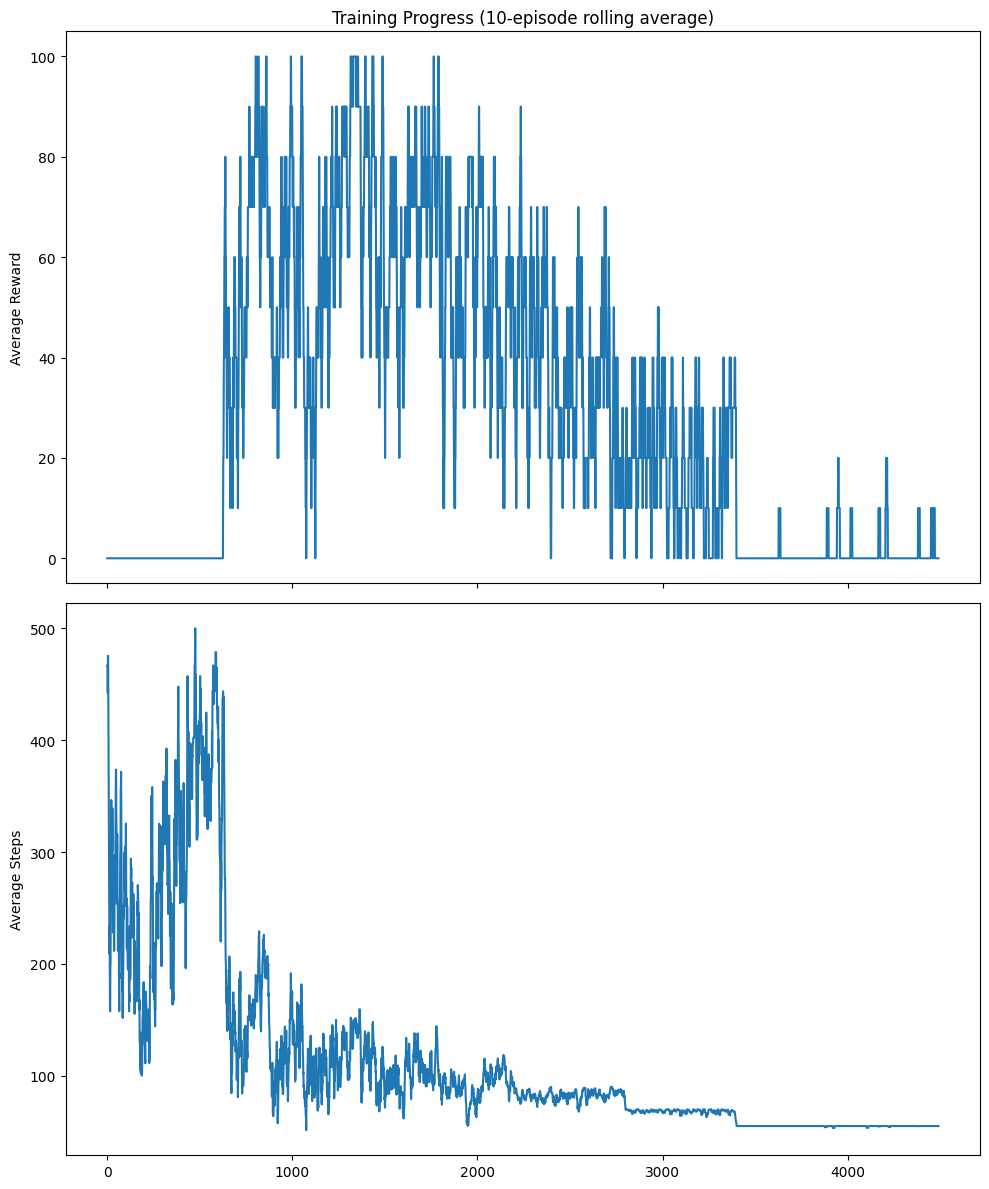

In [ ]:
import matplotlib.pyplot as plt

# Calculate rolling averages
window_size = 10
rolling_rewards = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
rolling_steps = np.convolve(steps_history, np.ones(window_size)/window_size, mode='valid')
rolling_success = np.convolve([1 if s else 0 for s in success_history], np.ones(window_size)/window_size, mode='valid') * 100

# Create the plots
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Plot rewards
ax1.plot(rolling_rewards)
ax1.set_ylabel('Average Reward')
ax1.set_title('Training Progress (10-episode rolling average)')

# Plot steps
ax2.plot(rolling_steps)
ax2.set_ylabel('Average Steps')

# Plot success rate
#ax3.plot(rolling_success)
#ax3.set_ylabel('Success Rate (%)')
#ax3.set_xlabel('Episode')

plt.tight_layout()
plt.show()

In [ ]:
# Create test environment
test_env = SailingEnv(**get_wind_scenario('training_3'))

# Test parameters
num_test_episodes = 50
max_steps = 500
num_crash = 0
average_step = []
print("Testing the trained agent on 5 new episodes...")
# Testing loop
for episode in range(num_test_episodes):
    # Reset environment
    observation, info = test_env.reset(seed=8000 + episode)  # Different seeds from training
    
    total_reward = 0
    
    for step in range(max_steps):
        # Select action using learned policy
        action = dqn_agent.act(observation)
        observation, reward, done, truncated, info = test_env.step(action)
        
        total_reward += reward
        
        # Break if episode is done
        if done or truncated:
            is_stuck = info.get('is_stuck', False)
            if is_stuck:
                print(f"Episode {episode+1}: CRASH dans l'île à l'étape {step+1}")
                num_crash += 1
            elif done:
                print(f"Episode {episode+1}: VICTOIRE (Bouée touchée) à l'étape {step+1}")
            else:
                print(f"Episode {episode+1}: Temps expiré (Truncated)")
            break
    average_step.append(step)    
    print(f"Test Episode {episode+1}: Steps={step+1}, Reward={total_reward}, " +
          f"Position={info['position']}, Goal reached={done}")
print(f"Le nombre de crash est {num_crash}")
print(f"average step : {np.mean(np.array(average_step))}")

Testing the trained agent on 5 new episodes...
Episode 1: VICTOIRE (Bouée touchée) à l'étape 126
Test Episode 1: Steps=126, Reward=100.0, Position=[ 63 127], Goal reached=True
Episode 2: VICTOIRE (Bouée touchée) à l'étape 119
Test Episode 2: Steps=119, Reward=100.0, Position=[ 64 127], Goal reached=True
Episode 3: VICTOIRE (Bouée touchée) à l'étape 135
Test Episode 3: Steps=135, Reward=100.0, Position=[ 64 127], Goal reached=True
Episode 4: VICTOIRE (Bouée touchée) à l'étape 132
Test Episode 4: Steps=132, Reward=100.0, Position=[ 63 126], Goal reached=True
Episode 5: VICTOIRE (Bouée touchée) à l'étape 125
Test Episode 5: Steps=125, Reward=100.0, Position=[ 63 126], Goal reached=True
Episode 6: VICTOIRE (Bouée touchée) à l'étape 132
Test Episode 6: Steps=132, Reward=100.0, Position=[ 63 127], Goal reached=True
Episode 7: VICTOIRE (Bouée touchée) à l'étape 97
Test Episode 7: Steps=97, Reward=100.0, Position=[ 64 127], Goal reached=True
Episode 8: VICTOIRE (Bouée touchée) à l'étape 123
Te

In [13]:
class NeuralNetwork:
    def __init__(self, input_size=44, hidden_size_1=128, hidden_size_2 = 128, output_size=9 ,learning_rate=0.001):
        super().__init__()
        self.np_random = np.random.default_rng()
        self.learning_rate = learning_rate
        # Linear parameters
        self.W1 = np.random.randn(input_size, hidden_size_1) * np.sqrt(2./input_size)
        self.b1 = np.zeros((1, hidden_size_1))
        self.W2 = np.random.randn(hidden_size_1, hidden_size_2) * np.sqrt(2./hidden_size_1)
        self.b2 = np.zeros((1, hidden_size_2))  
        self.W3 = np.random.randn(hidden_size_2, output_size) * np.sqrt(2./hidden_size_2)
        self.b3 = np.zeros((1, output_size))

    def forward(self, X):
        self.X = np.array(X)

        self.l1 = np.dot(X, self.W1) + self.b1
        self.relu1 = np.maximum(0, self.l1) 
        self.l2 = np.dot(self.relu1, self.W2) + self.b2
        self.relu2 = np.maximum(0, self.l2) 
        self.l3 = np.dot(self.relu2, self.W3) + self.b3
        return self.l3

    def backward(self, y_pred, y_true, weights=None):
        batch_size = y_pred.shape[0]

        delta = y_pred - y_true

        if weights is not None:
            delta *= weights[:, None]
        huber_delta = 1.0
        loss_grad = np.where(np.abs(delta) < huber_delta,
                            delta,
                            huber_delta * np.sign(delta))
        dl3 = loss_grad / batch_size 
        #dl3 = 2 * (y_pred - y_true) / batch_size #mse
        dW3 = np.dot(self.relu2.T, dl3)
        db3 = np.sum(dl3, axis=0, keepdims=True)

        drelu2 = np.dot(dl3, self.W3.T)
        dl2 = drelu2 * (self.l2 > 0)
        dW2 = np.dot(self.relu1.T, dl2)
        db2 = np.sum(dl2, axis=0, keepdims=True)

        drelu1 = np.dot(dl2, self.W2.T)
        dl1 = drelu1 * (self.l1 > 0)
        dW1 = np.dot(self.X.T, dl1)
        db1 = np.sum(dl1, axis=0, keepdims=True)

        max_grad = 10.0
        for grad in [dW1, db1, dW2, db2, dW3, db3]:
            np.clip(grad, -max_grad, max_grad, out=grad)

        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1


    def copy_weights(self):
        return {
            'W1': self.W1.copy(), 'b1': self.b1.copy(),
            'W2': self.W2.copy(), 'b2': self.b2.copy(),
            'W3': self.W3.copy(), 'b3': self.b3.copy()
        }  

    def update_weights(self, weights):
        self.W1 = weights['W1'].copy()
        self.b1 = weights['b1'].copy()
        self.W2 = weights['W2'].copy()
        self.b2 = weights['b2'].copy()
        self.W3 = weights['W3'].copy()
        self.b3 = weights['b3'].copy() 
        
class DQNAgent(BaseAgent):
    def __init__(self, hidden_size_1=128, hidden_size_2=128, memory_buffer = 100000, learning_rate=0.001, discount_factor=0.9, exploration_rate=0.1):
        super().__init__()
        self.np_random = np.random.default_rng()
        self.buffer_random = random.Random()        

        # Learning parameters
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate

        self.policy_net = NeuralNetwork(22, hidden_size_1, hidden_size_2, 9, self.learning_rate)
        self.target_net = NeuralNetwork(22, hidden_size_1, hidden_size_2, 9, self.learning_rate)
        self.update_weights_target() #pour initialiser avec les mêmes poids

        self.buffer = deque(maxlen=memory_buffer) #pour stocker en mémoire
        self.priorities = deque(maxlen=memory_buffer)
        self.priority_alpha = 0.6
        self.beta = 0.4
        self.beta_increment = 1e-4

    def get_features(self, observation, training=True):
        x, y = observation[0], observation[1]
        vx, vy = observation[2], observation[3]
        wx, wy = observation[4], observation[5]
        #flattened_wind_field = observation[6:6+32768].reshape(2, 128, 128)
        flattened_world = observation[6+32768:].reshape(128,128)
        if training :
            #randomisation du vent
            theta = self.np_random.uniform(-np.pi/2, np.pi/2)
            scale = self.np_random.uniform(0.7, 1.3)

            wx, wy = wx * scale, wy * scale

            wx_rot = wx * np.cos(theta) - wy * np.sin(theta)
            wy_rot = wx * np.sin(theta) + wy * np.cos(theta)

            wx, wy = wx_rot, wy_rot

        vx = np.clip(vx, -5, 5) / 5
        vy = np.clip(vy, -5, 5) / 5
        wx = np.clip(wx, -5, 5) / 5
        wy = np.clip(wy, -5, 5) / 5

        features = []
        v = np.sqrt(vx**2+vy**2)
        features.extend([x/128, y/128, vx, vy, v])

        #feature with goal
        goal = [64, 127]
        dx, dy = goal[0] - x, goal[1] - y
        dist_to_goal = np.sqrt(dx**2 + dy**2)
        norm = np.sqrt(128**2 + 128**2)
        angle_to_goal = np.arctan2(dy, dx)
        features.extend([dist_to_goal/norm, np.cos(angle_to_goal), np.sin(angle_to_goal)])

        #vmg
        if v>0.05:
            boat_angle = np.arctan2(vy, vx)
            vmg = v * np.cos(boat_angle - angle_to_goal)
        else :
            vmg = v
            boat_angle = angle_to_goal
        features.append(vmg)

        #feature angle with wind
        wind_angle = np.arctan2(wy, wx)
        relative_wind = abs((wind_angle - boat_angle + np.pi) % (2*np.pi) - np.pi)
        wind_goal_angle = abs((wind_angle - angle_to_goal + np.pi) % (2*np.pi) - np.pi)
        features.extend([np.cos(relative_wind), np.sin(relative_wind),np.cos(wind_goal_angle), np.sin(wind_goal_angle), np.sqrt(wx**2 + wy**2)])

        #feature of danger
        direction = [(0,1), (1,1), (1,0), (1,-1), (0,-1), (-1,-1), (-1,0), (-1,1)]
        #on choisit une direction et on crée une feature de danger par rapport à l'ile
        for direction_x, direction_y in direction: 
            danger = 0
            for distance in range(1,25):
                new_x = int(x + direction_x*distance)
                new_y = int(y + direction_y*distance)
                if 0 <= new_x < 128 and 0<= new_y < 128:
                    if flattened_world[new_x,new_y] == 1:
                        danger = (25 - distance)/25 
                        break
            features.append(danger)
        
        # #features with wind around
        # for direction_x, direction_y in direction:
        #     distance = 10
        #     new_x = int(x + direction_x*distance)
        #     new_y = int(y + direction_y*distance)
        #     if 0 <= new_x < 128 and 0<= new_y < 128:
        #         if training :
        #             new_wx = flattened_wind_field[0, new_x, new_y] * scale
        #             new_wy = flattened_wind_field[1, new_x, new_y] * scale

        #             new_wx_rot = new_wx * np.cos(theta) - new_wy * np.sin(theta)
        #             new_wy_rot = new_wx * np.sin(theta) + new_wy * np.cos(theta)

        #             new_wx = np.clip(new_wx_rot, -5, 5) / 5
        #             new_wy = np.clip(new_wy_rot, -5, 5) / 5
        #             features.append(new_wx - wx)
        #             features.append(new_wy - wy)
        #         else : 
        #             new_wx = flattened_wind_field[0, new_x, new_y]
        #             new_wy = flattened_wind_field[1, new_x, new_y]
        #             features.append(new_wx - wx)
        #             features.append(new_wy - wy)
        #     else :
        #         features.append(0)
        #         features.append(0)

        # #features gradient wind
        # int_x, int_y = int(x), int(y)
        # if 1 <= int_x < 127 and 1 <= int_y < 127:
        #     dwx_dx = flattened_wind_field[0, int_x+1, int_y] - flattened_wind_field[0, int_x-1, int_y]
        #     dwx_dy = flattened_wind_field[0, int_x, int_y+1] - flattened_wind_field[0, int_x, int_y-1]
        #     dwy_dx = flattened_wind_field[1, int_x+1, int_y] - flattened_wind_field[1, int_x-1, int_y]
        #     dwy_dy = flattened_wind_field[1, int_x, int_y+1] - flattened_wind_field[1, int_x, int_y-1]
        #     features.append(dwx_dx)
        #     features.append(dwx_dy)
        #     features.append(dwy_dx)
        #     features.append(dwy_dy)
        # else:
        #     features.append(0)
        #     features.append(0)
        #     features.append(0)
        #     features.append(0)

        #try to force to end in 40 steps
        # ideal_v = dist_to_goal / 40
        # v_deficit = ideal_v - v
        # features.append(np.clip(v_deficit, -5, 5) / 5.0)

        #features += np.random.normal(0, 0.01, size=len(features))
        
        return np.array(features)

    def act(self, observation, training=True):
        """Choose an action using epsilon-greedy policy."""
        state = self.get_features(observation, training).reshape(1, -1)
        # Epsilon-greedy action selection
        if self.np_random.random() < self.exploration_rate:
            return self.np_random.integers(0, 9)
        else:
            q_values = self.policy_net.forward(state)
            return int(np.argmax(q_values))

    def learn(self, observation, action, reward, next_observation, batch_size, done):
        """Update q_values based on observed transition."""
        state = self.get_features(observation, training=False)
        next_state = self.get_features(next_observation, training=False)

        self.buffer.append((state, action, reward, next_state, done))
        if len(self.priorities) > 0:
            max_priority = max(self.priorities)
        else :
            max_priority = 1

        self.priorities.append(max_priority)

        if len(self.buffer) < batch_size:
            return

        priorities = np.array(self.priorities, dtype=np.float32)
        probs = priorities ** self.priority_alpha
        probs /= probs.sum()

        indices = self.np_random.choice(len(self.buffer), batch_size, p=probs, replace=False)
        batch = [self.buffer[i] for i in indices]

        states, actions, rewards, next_states, dones = zip(*batch)

        states = np.array(states)
        next_states = np.array(next_states)
        rewards = np.array(rewards)
        dones = np.array(dones)
        actions = np.array(actions)

        weights = (len(self.buffer) * probs[indices]) ** (-self.beta)
        weights /= weights.max()

        current_q = self.policy_net.forward(states)
        next_q_target = self.target_net.forward(next_states)
        next_q_policy = self.policy_net.forward(next_states)

        targets = current_q.copy()
        td_errors = np.zeros(batch_size)

        for i in range(batch_size):
            target = rewards[i]

            if not dones[i]:
                best_action = np.argmax(next_q_policy[i])
                target += self.discount_factor * next_q_target[i, best_action]

            td_error = target - current_q[i, actions[i]]
            td_errors[i] = td_error

            targets[i, actions[i]] = current_q[i, actions[i]] + weights[i] * td_error

        self.policy_net.forward(states)
        self.policy_net.backward(current_q, targets, weights)

        for idx, td in zip(indices, td_errors):
            self.priorities[idx] = abs(td) + 1e-6
    def reset(self):
        """Reset the agent for a new episode."""
        # Nothing to reset
        pass
        
    def seed(self, seed=None):
        """Set the random seed."""
        self.np_random = np.random.default_rng(seed)
        self.buffer_random = random.Random(seed)
        self.policy_net.rng = np.random.default_rng(seed)
        self.target_net.rng = np.random.default_rng(seed) 
        
    def save(self, path):
        """Save the weights to a file."""
        with open(path, 'wb') as f:
            pickle.dump(self.policy_net.copy_weights(), f)
            
    def load(self, path):
        """Load the weights from a file."""
        with open(path, 'rb') as f:
            self.policy_net.update_weights(pickle.load(f))
            self.update_weights_target()
    
    def update_weights_target(self):
        self.target_net.update_weights(self.policy_net.copy_weights())

    def soft_update(self, tau=0.005):
        for attr in ['W1','b1','W2','b2','W3','b3']:
            target_param = getattr(self.target_net, attr)
            policy_param = getattr(self.policy_net, attr)

            updated = tau * policy_param + (1 - tau) * target_param
            setattr(self.target_net, attr, updated) 
        
dqn_agent = DQNAgent(hidden_size_1=64, hidden_size_2=64, memory_buffer = 50000, learning_rate=0.0005, discount_factor=0.97, exploration_rate=1)
max_steps = 500

np.random.seed(42)
dqn_agent.seed(42)

scenarios = ['training_1', 'training_2', 'training_3']
num_episodes = 4000
batch_size = 64
target_update_freq = 100

rewards_history = []
steps_history = []
success_history = []

best_avg_steps = 500
best_success = 0

eps_start = 1.0
eps_end = 0.03
eps_decay = 1200

start_time = time.time()
print(f"Starting full training with {num_episodes} episodes across 3 scenarios...")

for episode in range(num_episodes):
    # scenario = scenarios[episode % 3]
    #scenario = scenarios[np.random.randint(0, 3)]
    if episode < 1000:
        scenario = 'training_1'
    elif episode < 2000:
        scenario = scenarios[np.random.randint(0, 2)]
    else:
        scenario = scenarios[np.random.randint(0, 3)] 
    env = SailingEnv(**get_wind_scenario(scenario))
    goal = env.goal_position.copy()
    
    observation, info = env.reset(seed=episode)
    prev_dist = np.linalg.norm(info['position'] - goal)
    total_reward = 0
    previous_action = None

    if episode < 1000:
        current_max_steps = 500
    elif episode < 2000:
        current_max_steps = 150
    elif episode < 3000:
        current_max_steps = 100
    elif episode < 4000:
        current_max_steps = 80
    elif episode < 5000:
        current_max_steps = 100
    else:
        current_max_steps = 80

    for step in range(max_steps):
        action = dqn_agent.act(observation)
        next_observation, reward, done, truncated, info = env.step(action)
        
        #Reward 

        #VMG reward
        curr_speed = math.sqrt((info['velocity'][0])**2 + (info['velocity'][1])**2 )
        curr_angle_boat = math.atan2(info['velocity'][1], info['velocity'][0])
        curr_angle_to_goal = math.atan2(goal[1] - info['position'][1], goal[0] - info['position'][0])
        theta = curr_angle_boat - curr_angle_to_goal
        vmg_reward = curr_speed * math.cos(theta)

        #angle wind reward 
        curr_angle_wind = math.atan2(info['wind'][1], info['wind'][0])
        if curr_speed > 0.1:
            curr_angle_boat = math.atan2(info['velocity'][1], info['velocity'][0])
        else :
            curr_angle_boat = curr_angle_wind

        curr_angle = abs(math.degrees(curr_angle_wind - curr_angle_boat))
        if curr_angle > 180 :
            curr_angle = 360 - curr_angle
        if curr_angle < 40:
            wind_reward = -3.0 * (1 - curr_angle / 45)
        elif curr_angle < 60:
            wind_reward = -1.5 + (curr_angle - 45) * (1.0 / 15) 
        elif curr_angle < 75:
            wind_reward = -0.5 + (curr_angle - 60) * (1.0 / 15)
        elif curr_angle < 100:
            center = 87.5
            deviation = abs(curr_angle - center)
            wind_reward = 2.0 - (deviation / 12.5) * 0.5
        elif curr_angle < 140:
            wind_reward = 1.5 - (curr_angle - 100) * (0.3 / 40)
        elif curr_angle < 160:
            wind_reward = 1.2 - (curr_angle - 140) * (0.9 / 25)
        else:
            wind_reward = 0.3 - (curr_angle - 165) * (0.5 / 15) 
        
        #speed reward 
        speed_reward = curr_speed

        #time reward
        time_reward = -0.2
        #change action reward 
        action_reward = 0
        if previous_action != None and action != previous_action :
            action_reward = -0.05

        #distance reward
        curr_dist = np.linalg.norm(info['position'] - goal) 
        distance_reward = (prev_dist - dqn_agent.discount_factor*curr_dist)*5

        #distance to goal reward
        distance_to_goal_reward = -0.3 * (1.0 - curr_dist / 180.0)

        if step == 50 and (episode+1)%500 == 0:
            print(f"Distance: {distance_reward:.4f}")
            print(f"VMG: {vmg_reward:.4f}")
            print(f"Wind: {wind_reward:.4f}")
            print(f"Action Pen: {action_reward:.4f}")
        #shaped_reward = 10*reward + 1.5*speed_reward + time_reward + distance_to_goal_reward + 3*distance_reward + 7*vmg_reward + wind_reward + action_reward
        shaped_reward = 5*vmg_reward + 2*reward + 0.5*distance_reward + time_reward 
        if step == 50 and (episode+1)%500 == 0:
            print(f"TOTAL STEP REWARD: {shaped_reward:.4f}")


        if done and not info.get('is_stuck', False):
            time_bonus = (max_steps - step)
            shaped_reward += time_bonus
        if info.get('is_stuck', False):
            shaped_reward = -200.0
        prev_dist = curr_dist
        
        too_much_steps = current_max_steps * 0.6 
        if step > too_much_steps and not done:
            shaped_reward -= 1.0

        dqn_agent.learn(observation, action, shaped_reward, next_observation, batch_size, done)
        observation = next_observation
        previous_action = action
        total_reward += reward
        if step % 5 == 0:
            dqn_agent.soft_update(tau=0.005)

        if done or truncated:
            break

    rewards_history.append(total_reward)
    steps_history.append(step + 1)
    is_victory = done and not info.get('is_stuck', False)
    success_history.append(is_victory)

    dqn_agent.beta = min(1.0, dqn_agent.beta + dqn_agent.beta_increment)
    dqn_agent.exploration_rate = eps_end + (eps_start - eps_end) * np.exp(-episode / eps_decay)

    if episode == 1000:
        dqn_agent.policy_net.learning_rate = 0.0005
        dqn_agent.target_net.learning_rate = 0.0005
    elif episode == 2000:
        dqn_agent.policy_net.learning_rate = 0.0002
        dqn_agent.target_net.learning_rate = 0.0002
    elif episode == 3000:
        dqn_agent.policy_net.learning_rate = 0.0001
        dqn_agent.target_net.learning_rate = 0.0001



    if (episode + 1) % 100 == 0:
        recent = success_history[-100:]
        print(f"Episode {episode+1}/{num_episodes}: Success rate (last 100): {sum(recent)/len(recent)*100:.1f}%")

        recent_success = sum(success_history[-100:]) / 100
        recent_avg_steps = sum(steps_history[-100:]) / 100
        
        recent_steps = steps_history[-100:]
        fast_runs = sum(1 for s in recent_steps if s < 60)
        medium_runs = sum(1 for s in recent_steps if 60 <= s < 100)
        slow_runs = sum(1 for s in recent_steps if s >= 100)
        
        print(f"  Avg steps: {recent_avg_steps:.1f}")
        print(f"  Fast (<60): {fast_runs}%, Medium (60-100): {medium_runs}%, Slow (100+): {slow_runs}%")
        print(f"  Exploration rate: {dqn_agent.exploration_rate:.3f}")
        
        if recent_success >= 0.95 and recent_avg_steps < best_avg_steps:
            best_avg_steps = recent_avg_steps
            dqn_agent.save("best_sailing_model_high_vmg.pkl")
            print(f"Saved a new best model with average step {best_avg_steps}")

training_time = time.time() - start_time
success_rate = sum(success_history) / len(success_history) * 100
print(f"\nTraining completed in {training_time:.1f} seconds!")
print(f"Overall success rate: {success_rate:.1f}%")

Starting full training with 4000 episodes across 3 scenarios...
Episode 100/4000: Success rate (last 100): 0.0%
  Avg steps: 260.4
  Fast (<60): 10%, Medium (60-100): 1%, Slow (100+): 89%
  Exploration rate: 0.923
Episode 200/4000: Success rate (last 100): 0.0%
  Avg steps: 193.0
  Fast (<60): 16%, Medium (60-100): 9%, Slow (100+): 75%
  Exploration rate: 0.852
Episode 300/4000: Success rate (last 100): 0.0%
  Avg steps: 183.3
  Fast (<60): 31%, Medium (60-100): 14%, Slow (100+): 55%
  Exploration rate: 0.786
Episode 400/4000: Success rate (last 100): 0.0%
  Avg steps: 281.8
  Fast (<60): 14%, Medium (60-100): 12%, Slow (100+): 74%
  Exploration rate: 0.726
Distance: 27.8218
VMG: 2.4688
Wind: 1.4414
Action Pen: 0.0000
TOTAL STEP REWARD: 26.0550
Episode 500/4000: Success rate (last 100): 3.0%
  Avg steps: 266.1
  Fast (<60): 13%, Medium (60-100): 8%, Slow (100+): 79%
  Exploration rate: 0.670
Episode 600/4000: Success rate (last 100): 20.0%
  Avg steps: 204.3
  Fast (<60): 32%, Medium (

In [14]:
dqn_agent.save("last_sailing_model_opti_high_vmg.pkl")
print("Saved the last model")

Saved the last model


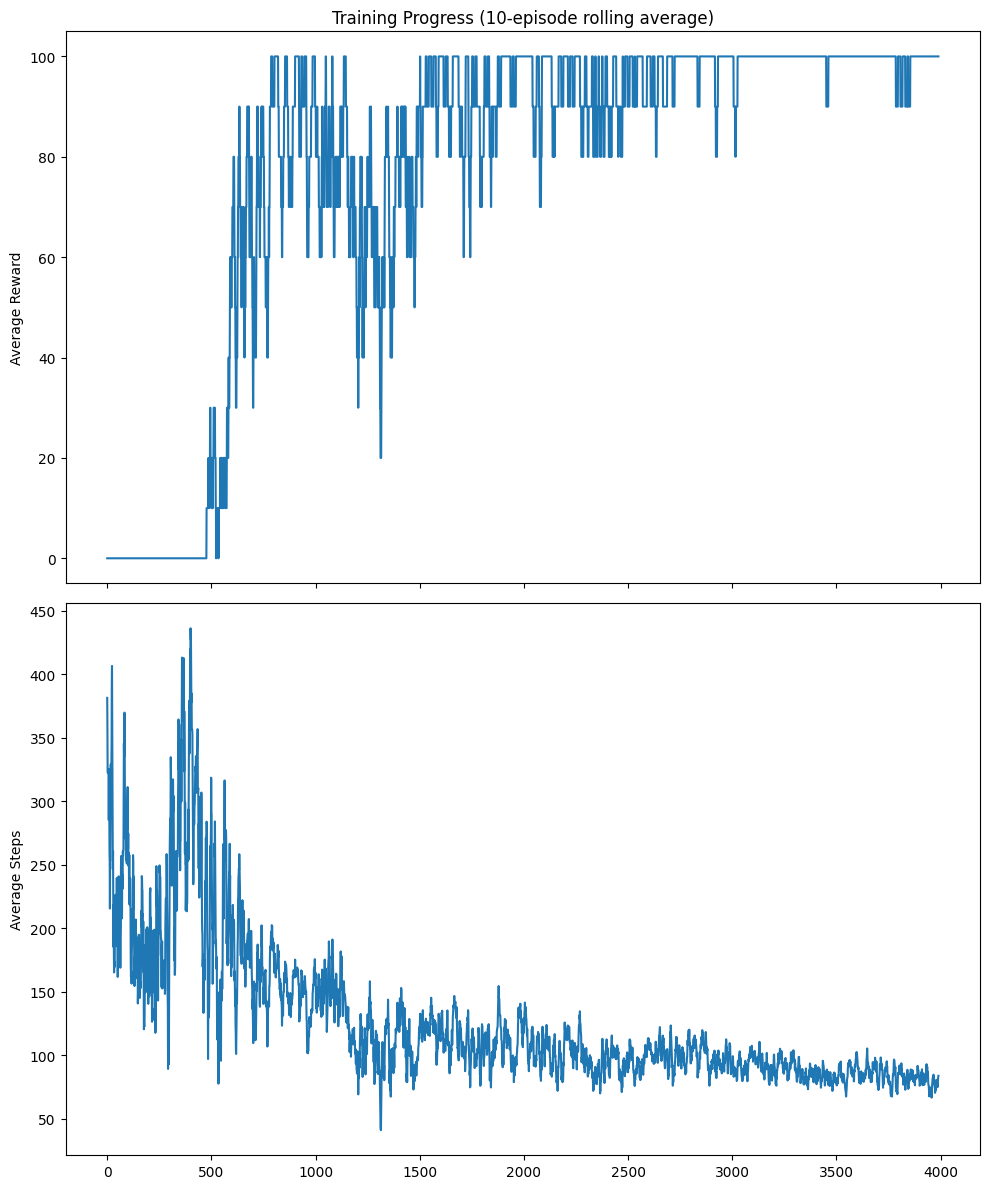

In [15]:
import matplotlib.pyplot as plt

# Calculate rolling averages
window_size = 10
rolling_rewards = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
rolling_steps = np.convolve(steps_history, np.ones(window_size)/window_size, mode='valid')
rolling_success = np.convolve([1 if s else 0 for s in success_history], np.ones(window_size)/window_size, mode='valid') * 100

# Create the plots
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Plot rewards
ax1.plot(rolling_rewards)
ax1.set_ylabel('Average Reward')
ax1.set_title('Training Progress (10-episode rolling average)')

# Plot steps
ax2.plot(rolling_steps)
ax2.set_ylabel('Average Steps')

# Plot success rate
#ax3.plot(rolling_success)
#ax3.set_ylabel('Success Rate (%)')
#ax3.set_xlabel('Episode')

plt.tight_layout()
plt.show()

In [16]:
# Create test environment
test_env = SailingEnv(**get_wind_scenario('training_3'))

# Test parameters
num_test_episodes = 50
max_steps = 500
num_crash = 0
average_step = []
print("Testing the trained agent on 5 new episodes...")
# Testing loop
for episode in range(num_test_episodes):
    # Reset environment
    observation, info = test_env.reset(seed=8000 + episode)  # Different seeds from training
    
    total_reward = 0
    
    for step in range(max_steps):
        # Select action using learned policy
        action = dqn_agent.act(observation)
        observation, reward, done, truncated, info = test_env.step(action)
        
        total_reward += reward
        
        # Break if episode is done
        if done or truncated:
            is_stuck = info.get('is_stuck', False)
            if is_stuck:
                print(f"Episode {episode+1}: CRASH dans l'île à l'étape {step+1}")
                num_crash += 1
            elif done:
                print(f"Episode {episode+1}: VICTOIRE (Bouée touchée) à l'étape {step+1}")
            else:
                print(f"Episode {episode+1}: Temps expiré (Truncated)")
            break
    average_step.append(step)    
    print(f"Test Episode {episode+1}: Steps={step+1}, Reward={total_reward}, " +
          f"Position={info['position']}, Goal reached={done}")
print(f"Le nombre de crash est {num_crash}")
print(f"average step : {np.mean(np.array(average_step))}")

Testing the trained agent on 5 new episodes...
Episode 1: VICTOIRE (Bouée touchée) à l'étape 109
Test Episode 1: Steps=109, Reward=100.0, Position=[ 63 127], Goal reached=True
Episode 2: VICTOIRE (Bouée touchée) à l'étape 99
Test Episode 2: Steps=99, Reward=100.0, Position=[ 64 127], Goal reached=True
Episode 3: VICTOIRE (Bouée touchée) à l'étape 102
Test Episode 3: Steps=102, Reward=100.0, Position=[ 64 127], Goal reached=True
Episode 4: VICTOIRE (Bouée touchée) à l'étape 98
Test Episode 4: Steps=98, Reward=100.0, Position=[ 63 127], Goal reached=True
Episode 5: VICTOIRE (Bouée touchée) à l'étape 91
Test Episode 5: Steps=91, Reward=100.0, Position=[ 64 127], Goal reached=True
Episode 6: VICTOIRE (Bouée touchée) à l'étape 102
Test Episode 6: Steps=102, Reward=100.0, Position=[ 64 127], Goal reached=True
Episode 7: VICTOIRE (Bouée touchée) à l'étape 93
Test Episode 7: Steps=93, Reward=100.0, Position=[ 63 127], Goal reached=True
Episode 8: VICTOIRE (Bouée touchée) à l'étape 106
Test Epi